# EFA Fitting and Checks

Runs EFA and post-EFA diagnostics. Edit the **Paths** cell before running.

**Post-EFA:** communalities, variance explained, factor loadings, and cross-loadings

In [100]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from langdetect import detect, LangDetectException
from collections import defaultdict
from sklearn.preprocessing import PowerTransformer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity, FactorAnalyzer
import joblib

from ep_pipeline.config import MetricsConfig
from ep_pipeline.io import load_csv, write_table
from ep_pipeline.efa.efa import prepare_features, scale_metrics, parallel_analysis, plot_scree, fit_efa
from ep_pipeline.efa.metric_taxonomy import CATEGORY_OF

## Paths

In [102]:
PROJECT_ROOT = Path('/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper')
TEXT_FP_DETECT = PROJECT_ROOT / 'data' / 'human_texts_2023_2025.csv'
CHR27_FP       = PROJECT_ROOT / 'data' / 'data_subset_chr27.csv'
IN_FP       = PROJECT_ROOT / 'data' / 'AO3metrics_full.csv'
VIS_DIR     = PROJECT_ROOT / 'outputs' / 'visualizations'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'efa_assumptions'
VIS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cfg = MetricsConfig()

In [103]:
# Run the imports cell + paths cell, then this cell instead of check_pre_efa_assumption.ipynb
STATE_PATH = PROJECT_ROOT / 'data' / 'efa_state.joblib'
_s = joblib.load(STATE_PATH)

scaled_metrics     = _s['scaled_metrics']
scaled_clean       = _s['scaled_clean']
corr_clean         = _s['corr_clean']
feature_cols       = _s['feature_cols']
keep_cols          = _s['keep_cols']
final_category_map = _s['final_category_map']
category_clean     = _s['category_clean']
n_obs              = _s['n_obs']
n_vars             = _s['n_vars']
meta_full          = _s['meta_full']

print(f"Loaded from {STATE_PATH}")
print(f"  scaled_metrics : {scaled_metrics.shape}")
print(f"  scaled_clean   : {scaled_clean.shape}  ({len(keep_cols)} vars)")
print(f"  meta_full      : {meta_full.shape}  (same row order as scaled_metrics/scaled_clean)")

Loaded from /Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper/data/efa_state.joblib
  scaled_metrics : (16966, 110)
  scaled_clean   : (16966, 74)  (74 vars)
  meta_full      : (16966, 25)  (same row order as scaled_metrics/scaled_clean)


## 1. Factor number — parallel analysis & scree

Retains factors whose eigenvalues exceed the 95th percentile from random data of the same shape.  
The Kaiser criterion (eigenvalue > 1) is shown for reference.

Parallel analysis suggests : 16 factor(s)
Kaiser criterion (eig > 1) : 17 factor(s)


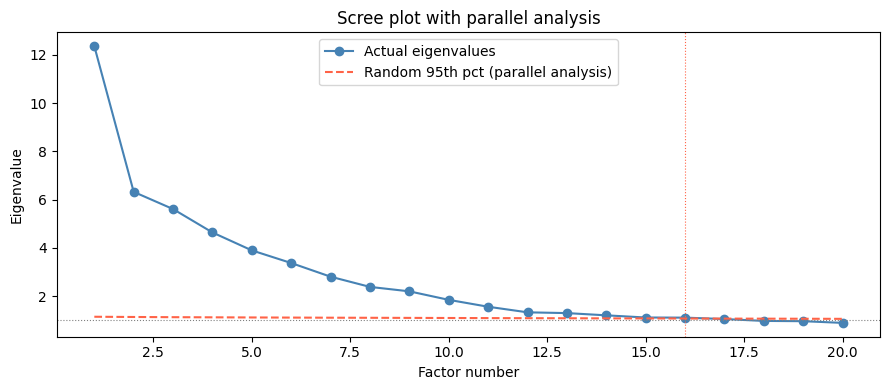

In [104]:
eigenvalues, pa_threshold, n_factors = parallel_analysis(
    scaled_clean, seed=cfg.seed, n_perm=cfg.n_permutations, percentile=99
)
n_kaiser = int((eigenvalues > 1).sum())
print(f'Parallel analysis suggests : {n_factors} factor(s)')
print(f'Kaiser criterion (eig > 1) : {n_kaiser} factor(s)')
plot_scree(eigenvalues, pa_threshold, n_factors, viz_path=VIS_DIR / 'efa_scree.png')
plt.show()


In [105]:
prev = 0
for k in range(1, 19):
    fa_k = FactorAnalyzer(n_factors=k, rotation='oblimin', method='minres')
    fa_k.fit(scaled_clean)
    var = fa_k.get_factor_variance()
    cumvar = var[2][-1] * 100
    print(f"k={k:2d}  cumulative variance: {cumvar:.1f}%  gain: +{cumvar - prev:.1f}%")
    prev = cumvar

/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


k= 1  cumulative variance: 15.9%  gain: +15.9%
k= 2  cumulative variance: 23.6%  gain: +7.7%
k= 3  cumulative variance: 30.4%  gain: +6.7%
k= 4  cumulative variance: 35.4%  gain: +5.0%
k= 5  cumulative variance: 40.3%  gain: +4.9%
k= 6  cumulative variance: 43.2%  gain: +2.9%
k= 7  cumulative variance: 45.8%  gain: +2.6%
k= 8  cumulative variance: 48.3%  gain: +2.5%
k= 9  cumulative variance: 50.6%  gain: +2.2%
k=10  cumulative variance: 52.0%  gain: +1.4%
k=11  cumulative variance: 52.6%  gain: +0.6%
k=12  cumulative variance: 53.6%  gain: +1.0%
k=13  cumulative variance: 54.2%  gain: +0.6%
k=14  cumulative variance: 55.2%  gain: +1.0%
k=15  cumulative variance: 55.8%  gain: +0.7%
k=16  cumulative variance: 56.5%  gain: +0.6%
k=17  cumulative variance: 56.8%  gain: +0.3%
k=18  cumulative variance: 57.3%  gain: +0.5%


### 10 factors chosen because parallel analysis supported up to 16 factors, but solution quality (weak/cross-loadings, communalities) plateaued by k=10-11, so we retained 10 factors for interpretability without sacrificing fit.

## 2. Fit EFA

Uses `n_factors` from parallel analysis above. Uncomment the override line if the scree plot or theory suggests a different number.

In [106]:
n_factors = 10  # uncomment to override

fa, loadings_df, var_df = fit_efa(
    scaled_clean, keep_cols, final_category_map, n_factors
)
print(var_df.to_string(index=False))
total_var = var_df['cumulative_pct'].iloc[-1]
var_pass  = 'PASS' if total_var >= 50 else 'NOTE — below 50%'
print(f'\nTotal variance explained: {total_var:.1f}%  ({var_pass})')

EFA fitted with 10 factors (oblimin rotation, minres estimation)
factor  SS_loadings  pct_var  cumulative_pct
    F1     6.149014 8.309478        8.309478
    F2     4.718034 6.375721       14.685200
    F3     4.659697 6.296888       20.982088
    F4     4.182791 5.652420       26.634508
    F5     3.964470 5.357392       31.991900
    F6     3.731520 5.042594       37.034494
    F7     3.587251 4.847636       41.882130
    F8     2.663291 3.599041       45.481172
    F9     2.500594 3.379181       48.860352
   F10     2.315051 3.128448       51.988800

Total variance explained: 52.0%  (PASS)


## 8. Communalities

Variables with `h2 < 0.10` are poorly explained by the retained factors so removed and refit without

Low communalities (h2 < 0.10): 2 variable(s)
dash_rate         0.057237
semicolon_rate    0.086568


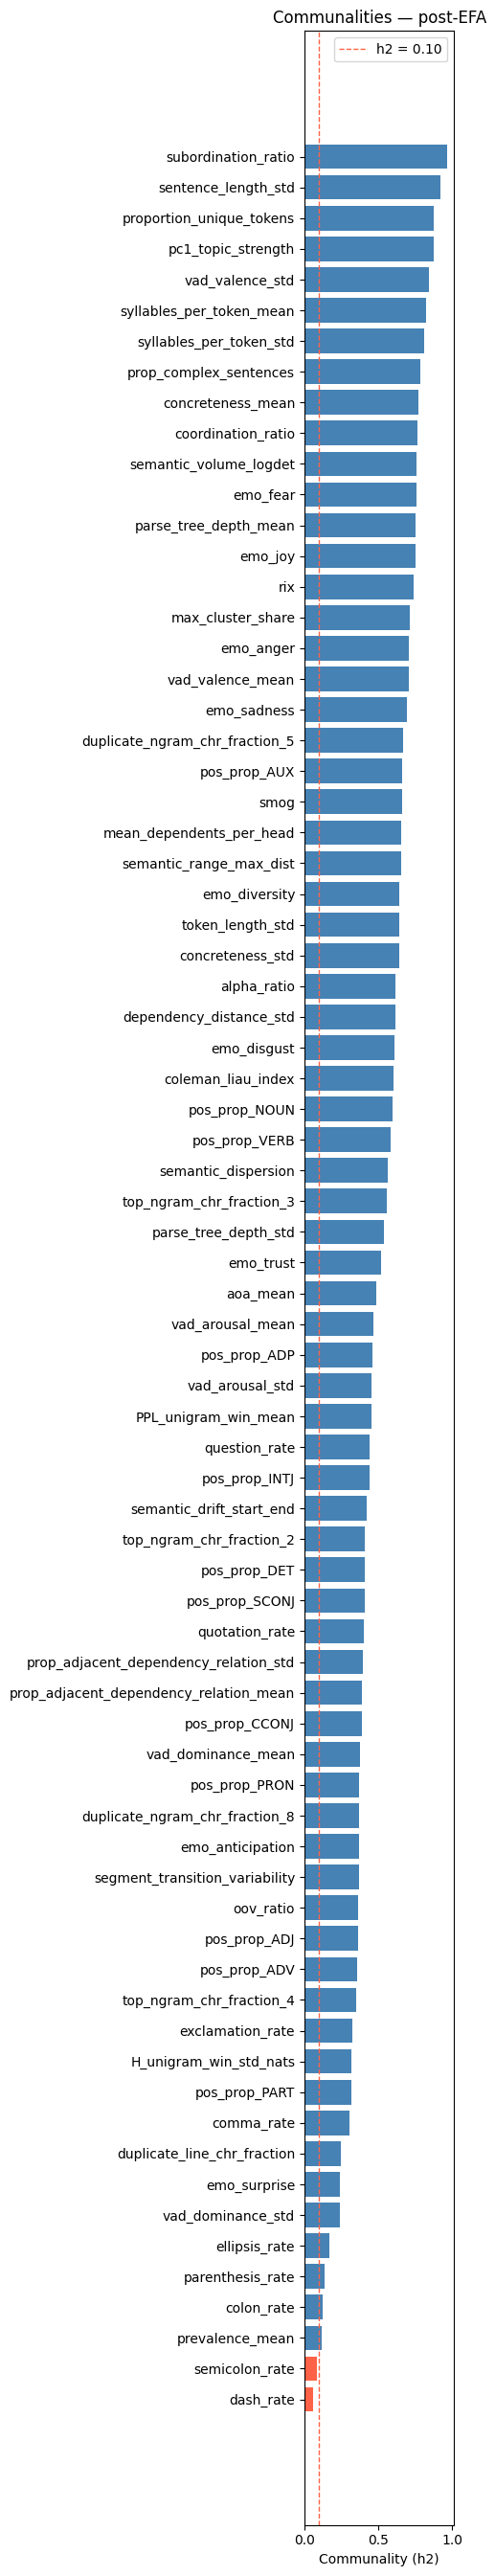

In [107]:
communalities = fa.get_communalities()
comm_series   = pd.Series(communalities, index=keep_cols).sort_values()
low_comm      = comm_series[comm_series < 0.1]
print(f'Low communalities (h2 < 0.10): {len(low_comm)} variable(s)')
if not low_comm.empty:
    print(low_comm.to_string())

fig, ax = plt.subplots(figsize=(5, max(6, n_vars // 4)))
colors  = ['tomato' if v < 0.1 else 'steelblue' for v in comm_series.values]
ax.barh(comm_series.index, comm_series.values, color=colors)
ax.axvline(0.1, color='tomato', linestyle='--', linewidth=1, label='h2 = 0.10')
ax.set_xlabel('Communality (h2)')
ax.set_title('Communalities — post-EFA')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_communalities.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Factor loadings & cross-loadings

- **Weak loaders** (`max |loading| < 0.20`): item does not load sufficiently on any factor — consider dropping  
- **Cross-loaders** (2nd highest loading > 75% of highest): item is ambiguous across factors — consider dropping

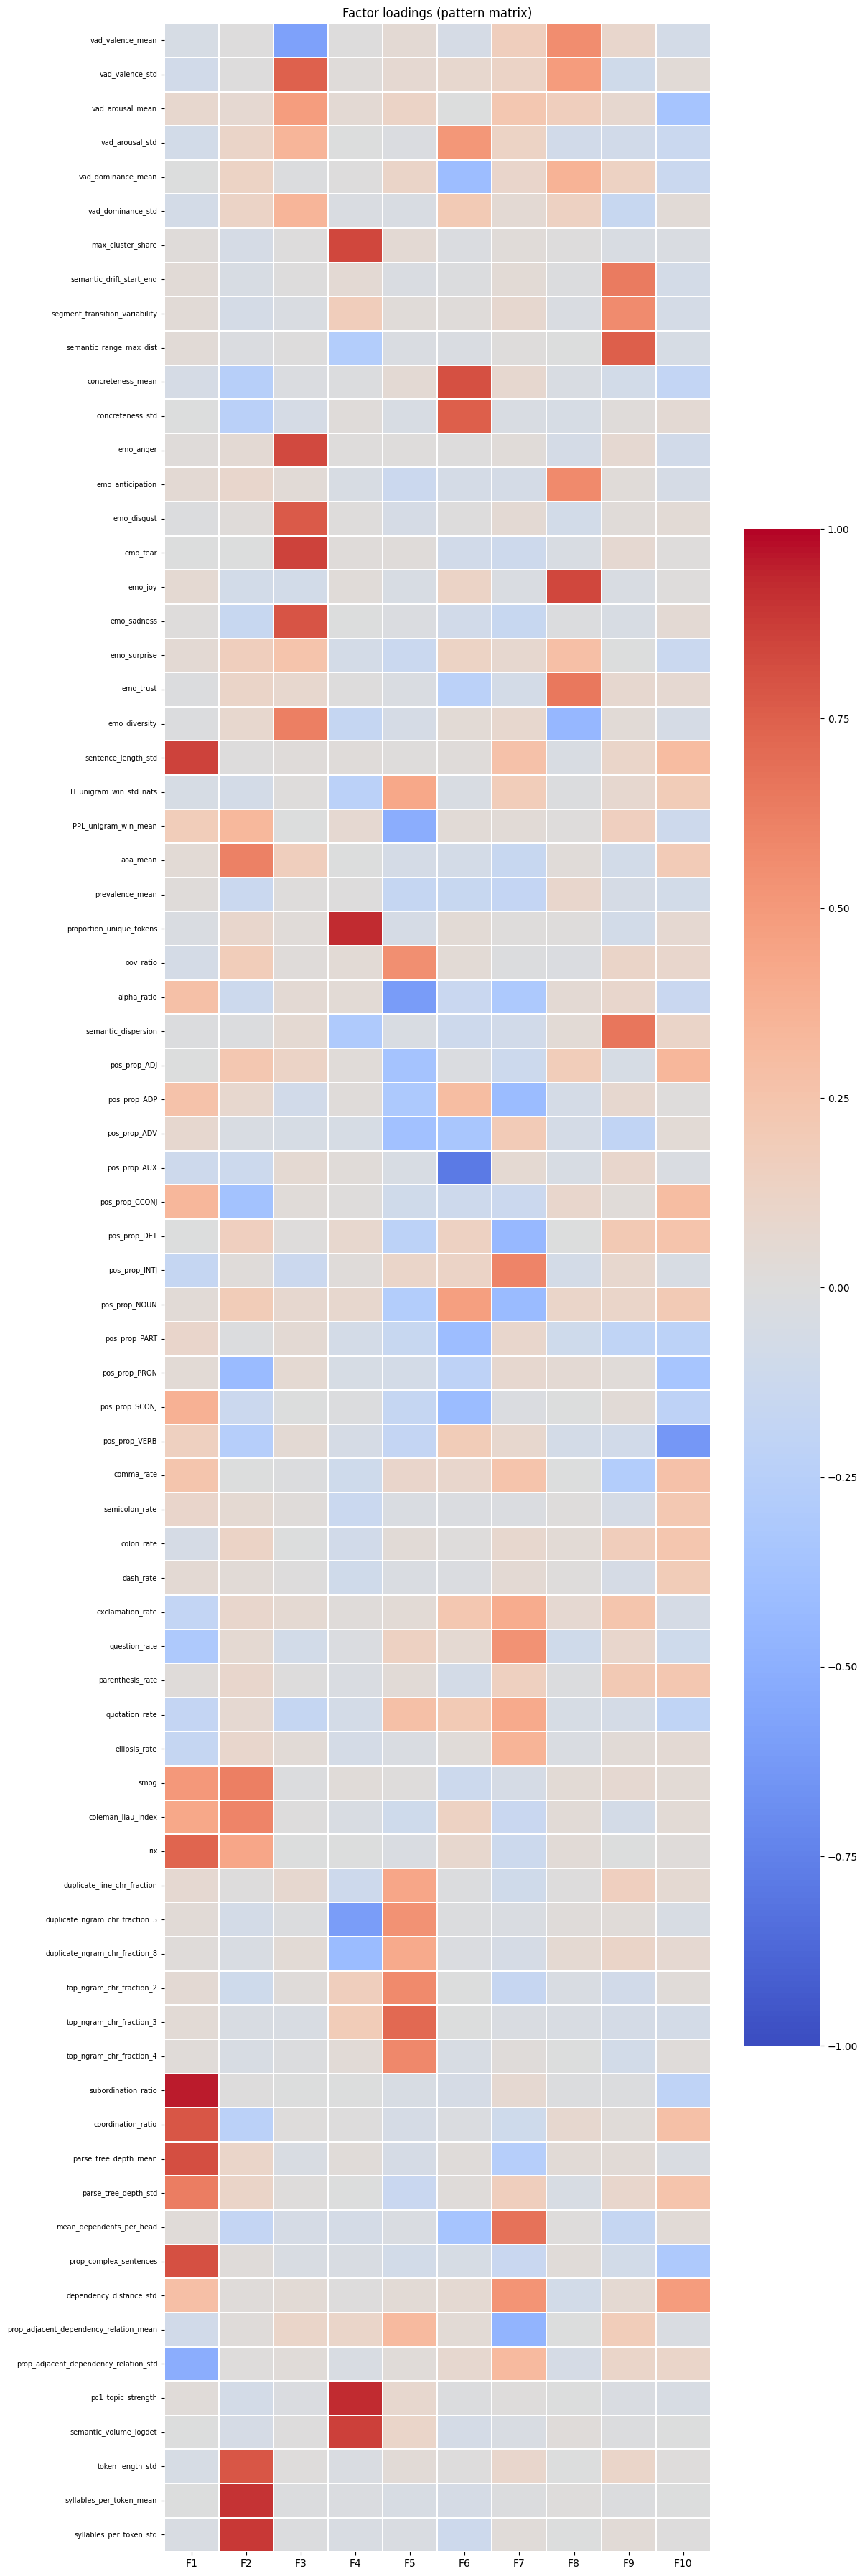

In [108]:
factor_col_names = [f'F{i+1}' for i in range(n_factors)]
loadings_vals    = loadings_df[factor_col_names]

annot = n_vars <= 40
fig, ax = plt.subplots(figsize=(max(6, n_factors + 2), max(8, n_vars // 3)))
sns.heatmap(
    loadings_vals, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=annot, fmt='.2f', linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Factor loadings (pattern matrix)')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_loadings_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [110]:
abs_loadings = loadings_vals.abs()
max_loading  = abs_loadings.max(axis=1)

weak_loaders = max_loading[max_loading < 0.2]
print(f'Weak loaders (max |loading| < 0.20): {len(weak_loaders)} variable(s)')
if not weak_loaders.empty:
    print(weak_loaders.to_string())

cross_loaders = []
for var in abs_loadings.index:
    row = abs_loadings.loc[var].sort_values(ascending=False)
    if n_factors >= 2 and row.iloc[1] > 0.75 * row.iloc[0]:
        cross_loaders.append({
            'variable':          var,
            'primary_factor':    row.index[0],
            'primary_loading':   row.iloc[0],
            'secondary_factor':  row.index[1],
            'secondary_loading': row.iloc[1],
        })

print(f'\nCross-loaders (2nd loading > 75% of 1st): {len(cross_loaders)} variable(s)')
if cross_loaders:
    print(pd.DataFrame(cross_loaders).to_string(index=False))

Weak loaders (max |loading| < 0.20): 2 variable(s)
prevalence_mean    0.173830
dash_rate          0.191897

Cross-loaders (2nd loading > 75% of 1st): 18 variable(s)
                      variable primary_factor  primary_loading secondary_factor  secondary_loading
              vad_valence_mean             F3         0.583494               F8           0.560154
            vad_dominance_mean             F6         0.408391               F8           0.367013
                  emo_surprise             F8         0.284693               F3           0.251216
               prevalence_mean             F7         0.173830               F5           0.169944
                  pos_prop_ADJ             F5         0.362353              F10           0.338829
                  pos_prop_ADP             F7         0.416483               F5           0.317415
                  pos_prop_ADV             F5         0.375892               F6           0.342512
                pos_prop_CCONJ             

## Drop poor variables and refit

Drop variables that appear in **both** weak loaders and low communality. Refit on `scaled_clean` / `keep_cols` (67 vars)

In [111]:
drop_iter1 = {
    'dash_rate', 'semicolon_rate', 'prevalence_mean'}

actually_dropped = drop_iter1 & set(keep_cols)
keep_cols2       = [c for c in keep_cols if c not in drop_iter1]
keep_idx2        = [keep_cols.index(c) for c in keep_cols2]
scaled_clean2    = scaled_clean[:, keep_idx2]

print(f"Dropped  : {sorted(actually_dropped)}")
print(f"Remaining: {len(keep_cols2)} variables  (was {len(keep_cols)})")

Dropped  : ['dash_rate', 'prevalence_mean', 'semicolon_rate']
Remaining: 71 variables  (was 74)


In [112]:
N_FACTORS2 = 10

fa2 = FactorAnalyzer(n_factors=N_FACTORS2, rotation='oblimin', method='minres')
fa2.fit(scaled_clean2)

loadings2    = pd.DataFrame(
    fa2.loadings_,
    index=keep_cols2,
    columns=[f'F{i+1}' for i in range(N_FACTORS2)]
)
var2         = fa2.get_factor_variance()
cumvar2      = var2[2][-1] * 100
print(f"EFA refit: {N_FACTORS2} factors, {len(keep_cols2)} variables")
print(f"Cumulative variance explained: {cumvar2:.1f}%")

EFA refit: 10 factors, 71 variables
Cumulative variance explained: 53.8%


In [113]:
# Communalities
comm2        = pd.Series(fa2.get_communalities(), index=keep_cols2).sort_values()
low_comm2    = comm2[comm2 < 0.1]
print(f"Low communalities (h2 < 0.10): {len(low_comm2)} variable(s)")
if not low_comm2.empty:
    print(low_comm2.to_string())

# Weak loaders
factor_cols2 = [f'F{i+1}' for i in range(N_FACTORS2)]
abs_load2    = loadings2[factor_cols2].abs()
max_load2    = abs_load2.max(axis=1)
weak2        = max_load2[max_load2 < 0.2]
print(f"\nWeak loaders (max |loading| < 0.20): {len(weak2)} variable(s)")
if not weak2.empty:
    print(weak2.to_string())

# Cross-loaders
cross2 = []
for var in abs_load2.index:
    row = abs_load2.loc[var].sort_values(ascending=False)
    if row.iloc[1] > 0.75 * row.iloc[0]:
        cross2.append({
            'variable':          var,
            'primary_factor':    row.index[0],
            'primary_loading':   round(row.iloc[0], 6),
            'secondary_factor':  row.index[1],
            'secondary_loading': round(row.iloc[1], 6),
        })
print(f"\nCross-loaders (2nd loading > 75% of 1st): {len(cross2)} variable(s)")
if cross2:
    print(pd.DataFrame(cross2).to_string(index=False))

Low communalities (h2 < 0.10): 0 variable(s)

Weak loaders (max |loading| < 0.20): 0 variable(s)

Cross-loaders (2nd loading > 75% of 1st): 15 variable(s)
                      variable primary_factor  primary_loading secondary_factor  secondary_loading
duplicate_ngram_chr_fraction_5             F4         0.609413               F5           0.535005
duplicate_ngram_chr_fraction_8             F4         0.421350               F5           0.409021
                  pos_prop_ADJ             F5         0.358497              F10           0.313709
                  pos_prop_ADV             F5         0.372884               F6           0.336228
                pos_prop_CCONJ             F2         0.371814              F10           0.305792
                 pos_prop_NOUN             F7         0.477505               F6           0.457130
                 pos_prop_PRON             F2         0.433307              F10           0.327689
                pos_prop_SCONJ             F6        

## Factor exploration

Salient variables (|loading| > 0.30) for each factor, sorted by magnitude. Use these to name the factors.

In [114]:
LOADING_THRESHOLD = 0.30

var2_arr = fa2.get_factor_variance()

for i, f in enumerate(factor_cols2):
    salient = loadings2[f][loadings2[f].abs() > LOADING_THRESHOLD].sort_values(key=abs, ascending=False)
    pct     = var2_arr[1][i] * 100
    print(f"\n{'='*72}")
    print(f"  {f}  |  {pct:.1f}% variance  |  {len(salient)} salient variables (|λ| > {LOADING_THRESHOLD})")
    print(f"{'='*72}")
    if len(salient) == 0:
        print("  (no variables above threshold)")
    for var, val in salient.items():
        cat = category_clean.get(var, '?')
        print(f"  {val:+.3f}  {var:<55}  [{cat}]")


  F1  |  8.5% variance  |  12 salient variables (|λ| > 0.3)
  +0.968  subordination_ratio                                      [Syntactic Complexity]
  +0.850  prop_complex_sentences                                   [Syntactic Complexity]
  +0.818  parse_tree_depth_mean                                    [Syntactic Complexity]
  +0.789  sentence_length_std                                      [Document Scale]
  +0.736  coordination_ratio                                       [Syntactic Complexity]
  +0.726  rix                                                      [Readability]
  +0.577  parse_tree_depth_std                                     [Syntactic Complexity]
  -0.541  prop_adjacent_dependency_relation_std                    [Syntax]
  +0.498  smog                                                     [Readability]
  +0.433  coleman_liau_index                                       [Readability]
  +0.397  pos_prop_SCONJ                                           [POS Distribution]


## Factor scores

Compute one score per factor per text using the fitted `fa2`, then save.

In [115]:
META_COLS = ['id', 'title', 'author', 'fandom', 'published', 'rating',
             'words', 'chapters', 'fandom_label', 'source']

# meta_full was loaded from efa_state.joblib — same row order as scaled_clean/scaled_clean2,
# already covers both source CSVs (chr27 + human_texts_2023_2025) since AO3metrics_full.csv does.
meta = meta_full[META_COLS].reset_index(drop=True)

# Compute factor scores — shape (n_texts, n_factors)
factor_scores = fa2.transform(scaled_clean2)
scores_df     = pd.DataFrame(factor_scores, columns=factor_cols2)

# Merge metadata + scores
result_df = pd.concat([meta, scores_df], axis=1)
print(f"Factor scores : {scores_df.shape}  (texts × factors)")
print(f"Result df     : {result_df.shape}  (texts × meta + factors)")

SCORES_PATH = PROJECT_ROOT / 'data' / 'efa_factor_scores.csv'
result_df.to_csv(SCORES_PATH, index=False)
print(f"\nSaved → {SCORES_PATH}")

result_df.head()

Factor scores : (16966, 10)  (texts × factors)
Result df     : (16966, 20)  (texts × meta + factors)

Saved → /Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper/data/efa_factor_scores.csv


,id,title,author,fandom,published,rating,words,chapters,fandom_label,source,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,53262055,river styx is high and wide,MelittaRilow,"['Hadestown - Mitchell', 'Ancient Greek Religi...",2024-01-24,['Mature'],8057.0,1/1,random,human,-0.186773,-0.700984,0.837594,-0.918279,-1.176615,1.058944,0.315300,0.570249,0.710319,1.480933
1,51560773,heard you got it so bad (i'm the best you'll n...,Anonymous,['Fall Out Boy'],2023-11-13,['Explicit'],5445.0,1/1,random,human,0.813925,-0.948484,-0.272239,-0.654175,-0.715007,1.149996,0.098757,-0.967251,-1.151534,-0.413066
2,51526354,Sisters,niamsagram,['The Rookie (TV 2018)'],2023-11-11,['General Audiences'],1351.0,1/1,random,human,-1.271360,-3.546188,-1.369806,0.702360,-0.007880,0.335195,0.538533,0.782028,-0.941722,-0.670490
3,66710050,"And Don't Forget, When Your Elders Forget",JadedWitch,['Wu Xian Nuan Nuan | Infinity Nikki (Video G...,2025-06-19,['Explicit'],47206.0,4/4,random,human,-1.560704,1.133275,0.590249,-1.601026,-0.795852,0.541283,-0.327291,-0.301504,-0.081508,0.458535
4,54786325,Dear Moor Monster of Mine,ThatGirlWithASquid,"['Stranger Things (TV 2016)', 'Wolfblood (TV)']",2024-04-12,['Teen And Up Audiences'],15746.0,3/4,random,human,0.488607,0.146974,0.179599,-1.345054,-1.993539,-0.595509,0.110663,-0.586158,0.344497,-0.184691


### Factor	Name	% var	Interpretation (high score = more of...)

F1	Syntactic Complexity	8.5%	subordination/coordination, parse depth, sentence-length variability, readability (sentence-length component)

F2	Lexical Sophistication	6.6%	syllable length, AoA, harder-vocabulary readability indices, fewer pronouns/CCONJ

F3	Negative Affect	6.6%	anger, fear, sadness, disgust, valence variance, low mean valence

F4	Lexical Richness	5.8%	unique tokens, topic strength, semantic volume, max cluster share, low duplication

F5	Repetitiveness	5.5%	top n-gram fractions, duplication, OOV, low alpha-ratio, fewer modifiers

F6	Concreteness	5.2%	concreteness, nouns, low auxiliaries/particles/adverbs

F7	Conversationality	5.1%	interjections, questions, quotations, exclamations, dependency-distance variability

F8	Positive Affect	3.7%	joy, trust, anticipation, positive valence

F9	Narrative Drift	3.5%	semantic dispersion, drift, transition variability

F10	Structural Variability	3.2%	sentence/dependency/parse-depth std, mixed POS signal*

\* overlaps with F1 (`sentence_length_std`) and F7 (`dependency_distance_std`), which are also salient there so likely picking up leftover variability variance rather than a fully distinct construct.